# Data Visualization for Actuaries
## A 90-Minute Practical Workshop

**Welcome!** In this session, we will explore essential data manipulation and visualization techniques using Python. You will learn to work with NumPy arrays, manipulate data with Pandas, and create compelling visualizations using Pandas and Seaborn.

[![Open in Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/01_data_visualization.ipynb)

### Session Overview
- **Part 1**: NumPy Basics — Arrays, indexing, and vectorized operations
- **Part 2**: Pandas Basics — DataFrames, data exploration, and aggregation
- **Part 3**: Plotting with Pandas — Creating informative visualizations
- **Part 4**: Advanced Visualization — Seaborn distributions and pairplots

*Duration*: 90 minutes  
*Audience*: Actuaries and quantitative professionals  
*Prerequisites*: Basic Python knowledge


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mytools import generate_sample_insurance_data

# Set visualization defaults
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## Part 1: NumPy Basics

NumPy is the foundation of numerical computing in Python. It provides efficient arrays and vectorized operations that are essential for data analysis and scientific computing.

### 1.1 Creating Arrays from Nested Lists

You can create NumPy arrays from Python lists. NumPy arrays can be multi-dimensional:

| Dimension | Example | Description |
|-----------|---------|-------------|
| 1D | `np.array([1, 2, 3])` | A single row or column |
| 2D | `np.array([[1, 2], [3, 4]])` | A matrix with rows and columns |
| 3D+ | Higher-dimensional structures | For complex data |

**Key advantages of NumPy arrays:**
- Efficient memory usage
- Fast vectorized operations
- Broadcasting across different array shapes
- Seamless integration with other libraries

### 1.2 Array Indexing and Slicing

Once you have an array, you can access elements in multiple ways:

```python
arr = np.array([10, 20, 30, 40, 50])
arr[0]        # First element: 10
arr[-1]       # Last element: 50
arr[1:4]      # Elements from index 1 to 3: [20, 30, 40]
arr[::2]      # Every second element: [10, 30, 50]
```

For 2D arrays, you use `arr[row, column]` or `arr[row][column]`.

### 1.3 Universal Functions (ufuncs)

Universal functions perform element-wise operations on arrays. Common ufuncs include:

- `np.sqrt()` — Square root
- `np.exp()` — Exponential function
- `np.log()` — Natural logarithm
- `np.sin()`, `np.cos()` — Trigonometric functions
- `np.abs()` — Absolute value

These operations are **vectorized**, meaning they apply to all elements simultaneously without explicit loops.

### Example: Insurance Premium Calculation
Suppose you have an array of base premiums and want to apply a 10% loading. With NumPy:

$$\text{Loaded Premium} = \text{Base Premium} \times 1.10$$


In [2]:
# Example: Creating and manipulating NumPy arrays
base_premiums = np.array([500, 750, 1000, 1200, 950])

# Apply a 10% loading
loaded_premiums = base_premiums * 1.10

print("Base Premiums:", base_premiums)
print("Loaded Premiums:", loaded_premiums)

# Create a 2D array (matrix) of premium data
# Rows: policyholders, Columns: base, loading, final
premium_data = np.array([
    [500, 50, 550],
    [750, 75, 825],
    [1000, 100, 1100],
    [1200, 120, 1320],
    [950, 95, 1045]
])

print("\nPremium Data (2D Array):")
print(premium_data)

# Access individual elements
print("\nFirst policyholder's final premium:", premium_data[0, 2])

# Access a column (all final premiums)
print("All final premiums:", premium_data[:, 2])

# Access a row (first policyholder's data)
print("First policyholder's data:", premium_data[0, :])


Base Premiums: [ 500  750 1000 1200  950]
Loaded Premiums: [ 550.  825. 1100. 1320. 1045.]

Premium Data (2D Array):
[[ 500   50  550]
 [ 750   75  825]
 [1000  100 1100]
 [1200  120 1320]
 [ 950   95 1045]]

First policyholder's final premium: 550
All final premiums: [ 550  825 1100 1320 1045]
First policyholder's data: [500  50 550]


### 1.4 Exercise: NumPy Fundamentals

Complete the following tasks:

1. Create a 1D array of claim amounts: `[100, 250, 500, 1500, 350]`
2. Apply a logarithmic transformation using `np.log()` (useful for skewed claim data)
3. Create a 2D array of risk factors and premiums
4. Extract and manipulate specific elements using indexing

**Instructions:**
- Fill in the code cells below to complete each task
- Experiment with different indexing and slicing techniques
- Verify your results by printing the output


In [3]:
# Task 1: Create a 1D array of claim amounts and apply log transformation
claim_amounts = np.array([100, 250, 500, 1500, 350])
log_claims = np.log(claim_amounts)

print("Original claim amounts:", claim_amounts)
print("Log-transformed claims:", log_claims)

# Task 2: Create a 2D array with policyholder risk factors and corresponding premiums
# Columns: [risk_factor, base_premium, adjusted_premium]
risk_premium_data = np.array([
    [1.0, 500, 500],
    [1.15, 500, 575],
    [1.35, 500, 675],
    [2.0, 500, 1000],
    [0.8, 500, 400]
])

print("\nRisk Premium Data:")
print(risk_premium_data)

# Task 3: Extract specific elements
# Get the adjusted premium for the third policyholder
third_premium = risk_premium_data[2, 2]
print(f"\nThird policyholder's adjusted premium: {third_premium}")

# Task 4: Extract all adjusted premiums (last column)
all_adjusted = risk_premium_data[:, 2]
print(f"All adjusted premiums: {all_adjusted}")

# Bonus: Apply a universal function - calculate square root of risk factors
risk_factors = risk_premium_data[:, 0]
sqrt_risk = np.sqrt(risk_factors)
print(f"\nSquare root of risk factors: {sqrt_risk}")


Original claim amounts: [ 100  250  500 1500  350]
Log-transformed claims: [4.60517019 5.52146092 6.2146081  7.31322039 5.85793315]

Risk Premium Data:
[[1.00e+00 5.00e+02 5.00e+02]
 [1.15e+00 5.00e+02 5.75e+02]
 [1.35e+00 5.00e+02 6.75e+02]
 [2.00e+00 5.00e+02 1.00e+03]
 [8.00e-01 5.00e+02 4.00e+02]]

Third policyholder's adjusted premium: 675.0
All adjusted premiums: [ 500.  575.  675. 1000.  400.]

Square root of risk factors: [1.         1.07238053 1.161895   1.41421356 0.89442719]


## Part 2: Pandas Basics

Pandas is built on top of NumPy and provides the `Series` and `DataFrame` objects. A DataFrame is like a spreadsheet with labeled columns and rows, making data manipulation intuitive.

### 2.1 Creating Series from Dictionaries

A Series is a one-dimensional labeled array. You can create it from a dictionary:

```python
age_series = pd.Series({'Alice': 28, 'Bob': 35, 'Carol': 42})
```

The dictionary keys become the index, and the values become the data.

### 2.2 Creating DataFrames

You can combine multiple Series to form a DataFrame:

```python
df = pd.DataFrame({
    'age': [28, 35, 42],
    'premium': [500, 750, 1000],
    'region': ['North', 'South', 'East']
})
```

Or from a dictionary of Series, ensuring all have the same index.

### 2.3 Accessing Data

Pandas provides multiple ways to access data:

| Method | Purpose | Example |
|--------|---------|---------|
| `.loc[]` | Label-based access | `df.loc[0, 'age']` |
| `.iloc[]` | Position-based access | `df.iloc[0, 1]` |
| `df[column]` | Access entire column | `df['age']` |
| `df.at[]` | Fast scalar access | `df.at[0, 'age']` |

### 2.4 Data Exploration Methods

Pandas provides convenient methods for understanding your data:

```python
df.head()           # First 5 rows
df.tail()           # Last 5 rows
df.info()           # Data types and non-null counts
df.describe()       # Statistical summary
df.columns          # Column names
df.dtypes           # Data types
df.isna().sum()     # Count missing values per column
df['column'].unique()      # Unique values
df['column'].value_counts() # Value frequencies
```

### 2.5 Grouping and Aggregation

A powerful feature for actuarial analysis is grouping:

```python
df.groupby('region')['premium'].mean()
```

This groups by region and calculates the mean premium per region.


In [4]:
# Load sample insurance data
df = generate_sample_insurance_data(n=300, seed=42)

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Display data info
print("\n" + "="*50)
print("Dataset Information:")
print("="*50)
df.info()

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())


First 5 rows of the dataset:
   policyholder_id  age  gender   region vehicle_type  annual_premium  \
0                1   56  Female     East    Mid-range         1755.21   
1                2   69    Male     West    Mid-range         1344.78   
2                3   46  Female  Central          SUV          590.09   
3                4   32    Male     West      Compact         1417.90   
4                5   60  Female     East       Luxury         1482.04   

   claims_count  claim_amount  
0             1        811.11  
1             0          0.00  
2             2       2594.37  
3             3       1761.43  
4             1        641.49  

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   policyholder_id  300 non-null    int64  
 1   age              300 non-null    int64  
 2   gender           300 non-null    str

In [5]:
# Explore column names and data types
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isna().sum())

# Examine unique values in categorical columns
print("\nUnique Regions:")
print(df['region'].unique())

print("\nUnique Vehicle Types:")
print(df['vehicle_type'].unique())

print("\nGender Distribution:")
print(df['gender'].value_counts())


Column Names:
['policyholder_id', 'age', 'gender', 'region', 'vehicle_type', 'annual_premium', 'claims_count', 'claim_amount']

Data Types:
policyholder_id      int64
age                  int64
gender                 str
region                 str
vehicle_type           str
annual_premium     float64
claims_count         int64
claim_amount       float64
dtype: object

Missing Values:
policyholder_id    0
age                0
gender             0
region             0
vehicle_type       0
annual_premium     0
claims_count       0
claim_amount       0
dtype: int64

Unique Regions:
<StringArray>
['East', 'West', 'Central', 'North', 'South']
Length: 5, dtype: str

Unique Vehicle Types:
<StringArray>
['Mid-range', 'SUV', 'Compact', 'Luxury']
Length: 4, dtype: str

Gender Distribution:
gender
Male          152
Female        135
Non-binary     13
Name: count, dtype: int64


### 2.4 Reading and Writing CSV Files

One of the most common tasks in data analysis is **reading data from files** and **writing results back**.
Pandas makes this remarkably straightforward with `to_csv()` and `read_csv()`.

| Method | Description | Example |
|--------|-------------|----------|
| `df.to_csv('file.csv', index=False)` | Write DataFrame to a CSV file | Export for sharing or archiving |
| `pd.read_csv('file.csv')` | Read a CSV file into a DataFrame | Load external data for analysis |

> **Tip:** Use `index=False` when writing to avoid saving the DataFrame index as an extra column.

In [6]:
# Write the insurance DataFrame to a CSV file
df.to_csv('insurance_sample.csv', index=False)
print('Data written to insurance_sample.csv')

# Read the CSV file back into a new DataFrame
df_loaded = pd.read_csv('insurance_sample.csv')

# Verify that the loaded data matches the original
print(f'Original shape:  {df.shape}')
print(f'Loaded shape:    {df_loaded.shape}')
print(f'Data identical:  {df.equals(df_loaded)}')
df_loaded.head(3)

Data written to insurance_sample.csv
Original shape:  (300, 8)
Loaded shape:    (300, 8)
Data identical:  True


,policyholder_id,age,gender,region,vehicle_type,annual_premium,claims_count,claim_amount
0,1,56,Female,East,Mid-range,1755.21,1,811.11
1,2,69,Male,West,Mid-range,1344.78,0,0.00
2,3,46,Female,Central,SUV,590.09,2,2594.37


### 2.6 Exercise: Pandas Data Exploration

You will now explore the insurance dataset using Pandas methods. The data has already been loaded. Perform the following tasks:

1. **Examine the dataset structure** using `.head()`, `.info()`, and `.describe()`
2. **Analyze categorical columns** using `.unique()` and `.value_counts()`
3. **Compute grouped aggregations**:
   - Average premium by region
   - Average claims count by vehicle type
   - Count of policyholders by gender

**Instructions:**
- Use the provided code cells below
- Experiment with different grouping and aggregation combinations
- Interpret the results in an actuarial context


In [7]:
# Task 1: Get basic statistics for selected columns
print("Age Statistics:")
print(df['age'].describe())

print("\nPremium Statistics:")
print(df['annual_premium'].describe())

# Task 2: Analyze the relationship between age groups and claims
# Create age bins
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 100], labels=['<30', '30-40', '40-50', '50+'])

print("\nPolicyholders by Age Group:")
print(df['age_group'].value_counts().sort_index())


Age Statistics:
count    300.000000
mean      45.876667
std       16.870988
min       18.000000
25%       31.750000
50%       45.000000
75%       60.250000
max       75.000000
Name: age, dtype: float64

Premium Statistics:
count     300.000000
mean     1842.409800
std       869.436167
min       418.540000
25%      1227.600000
50%      1691.510000
75%      2323.035000
max      5013.770000
Name: annual_premium, dtype: float64

Policyholders by Age Group:
age_group
<30       69
30-40     47
40-50     60
50+      124
Name: count, dtype: int64


In [8]:
# Task 3: Group and aggregate - Premium by Region
premium_by_region = df.groupby('region')['annual_premium'].agg(['mean', 'median', 'count'])
print("Premium Analysis by Region:")
print(premium_by_region)

# Task 4: Group and aggregate - Claims count by Vehicle Type
claims_by_vehicle = df.groupby('vehicle_type')['claims_count'].agg(['mean', 'sum', 'count'])
print("\nClaims Analysis by Vehicle Type:")
print(claims_by_vehicle)

# Task 5: Group and aggregate - Multiple columns
region_gender_premium = df.groupby(['region', 'gender'])['annual_premium'].mean().unstack()
print("\nAverage Premium by Region and Gender:")
print(region_gender_premium)


Premium Analysis by Region:
                mean    median  count
region                               
Central  1945.722833  1823.145     60
East     1758.096949  1555.610     59
North    1857.658308  1734.240     65
South    1833.275238  1654.780     63
West     1811.466415  1696.870     53

Claims Analysis by Vehicle Type:
                  mean  sum  count
vehicle_type                      
Compact       1.298851  113     87
Luxury        1.268293   52     41
Mid-range     0.950980   97    102
SUV           1.214286   85     70

Average Premium by Region and Gender:
gender        Female         Male   Non-binary
region                                        
Central  1966.006552  1947.482222  1786.790000
East     1601.273929  1899.743548          NaN
North    1808.545667  1875.566061  2298.870000
South    1783.971000  1871.433125  2091.350000
West     1821.082222  1853.997586  1577.051667


## Part 3: Plotting with Pandas

Pandas integrates seamlessly with Matplotlib, making it easy to create visualizations directly from DataFrames. Common plot types include:

### 3.1 Scatter Plots

Scatter plots show the relationship between two continuous variables. In insurance, we might visualize:
- Age vs. Premium (does older age command higher premiums?)
- Claims count vs. Claim amount (do frequent claimants have larger claims?)

```python
df.plot.scatter(x='age', y='annual_premium', alpha=0.6)
```

The `alpha` parameter controls transparency, useful when points overlap.

### 3.2 Bar Charts

Bar charts compare categorical data. Common applications:
- Average premium by region
- Claim frequency by vehicle type
- Policyholder counts by gender

```python
df.groupby('region')['annual_premium'].mean().plot(kind='bar')
```

### 3.3 Histograms

Histograms show the distribution of a continuous variable:
- Premium distributions (are they normally distributed?)
- Claim amounts (are they skewed?)
- Age distribution of portfolio

```python
df['annual_premium'].plot.hist(bins=30, edgecolor='black')
```

### Key Visualization Principles
1. **Label axes clearly** with units
2. **Use informative titles** that state what is being shown
3. **Choose appropriate plot types** for your data
4. **Consider color and transparency** for clarity
5. **Add legends** when multiple series are shown


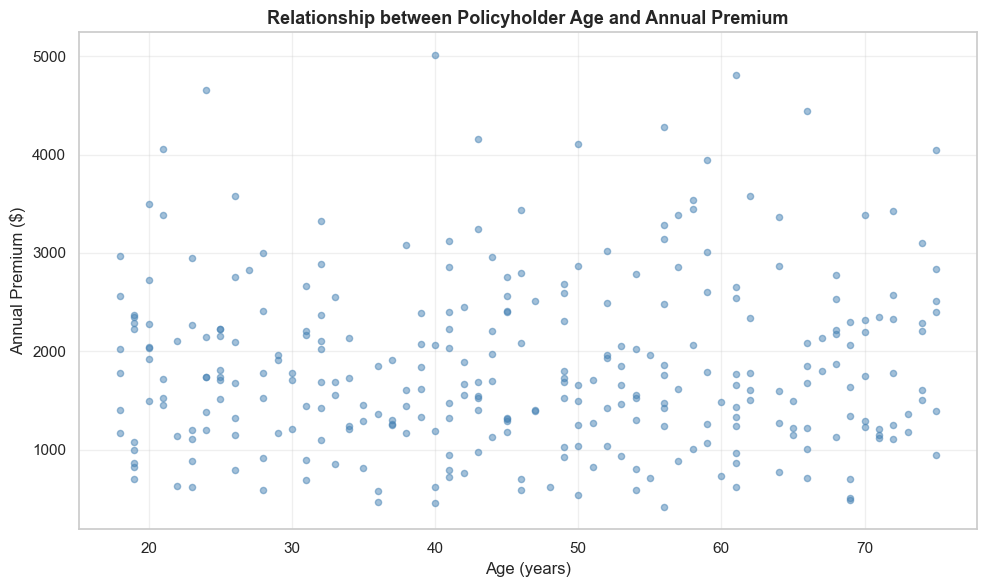

Correlation between age and premium: 0.033


In [9]:
# Plot 1: Scatter plot - Age vs. Premium
fig, ax = plt.subplots(figsize=(10, 6))
df.plot.scatter(x='age', y='annual_premium', alpha=0.5, ax=ax, color='steelblue')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Annual Premium ($)', fontsize=12)
ax.set_title('Relationship between Policyholder Age and Annual Premium', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Correlation between age and premium:", df['age'].corr(df['annual_premium']).round(3))


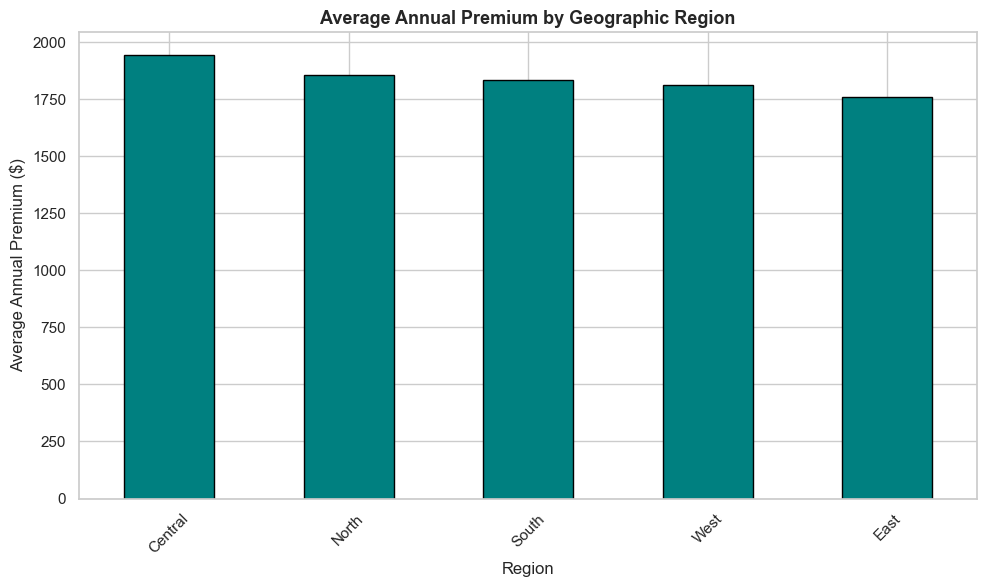

In [10]:
# Plot 2: Bar chart - Average Premium by Region
fig, ax = plt.subplots(figsize=(10, 6))
avg_premium_region = df.groupby('region')['annual_premium'].mean().sort_values(ascending=False)
avg_premium_region.plot(kind='bar', ax=ax, color='teal', edgecolor='black')
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Average Annual Premium ($)', fontsize=12)
ax.set_title('Average Annual Premium by Geographic Region', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


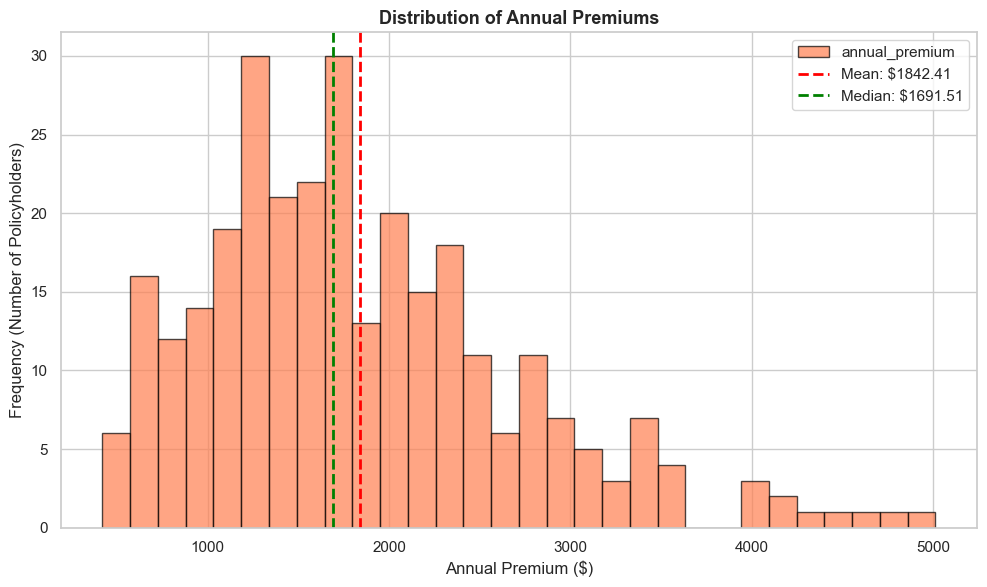

Mean Premium: $1842.41
Median Premium: $1691.51
Std Dev: $869.44


In [11]:
# Plot 3: Histogram - Distribution of Premium Amounts
fig, ax = plt.subplots(figsize=(10, 6))
df['annual_premium'].plot.hist(bins=30, ax=ax, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Annual Premium ($)', fontsize=12)
ax.set_ylabel('Frequency (Number of Policyholders)', fontsize=12)
ax.set_title('Distribution of Annual Premiums', fontsize=13, fontweight='bold')
ax.axvline(df['annual_premium'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["annual_premium"].mean():.2f}')
ax.axvline(df['annual_premium'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df["annual_premium"].median():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean Premium: ${df['annual_premium'].mean():.2f}")
print(f"Median Premium: ${df['annual_premium'].median():.2f}")
print(f"Std Dev: ${df['annual_premium'].std():.2f}")


### 3.4 Exercise: Creating Pandas Visualizations

Create visualizations that answer these actuarial questions:

1. **How does claim amount vary by vehicle type?** (Bar chart)
2. **What is the distribution of claims count?** (Histogram)
3. **Is there a relationship between age and claims count?** (Scatter plot)

**Instructions:**
- Write code to create each visualization
- Add appropriate titles, labels, and legends
- Interpret the results in an insurance context


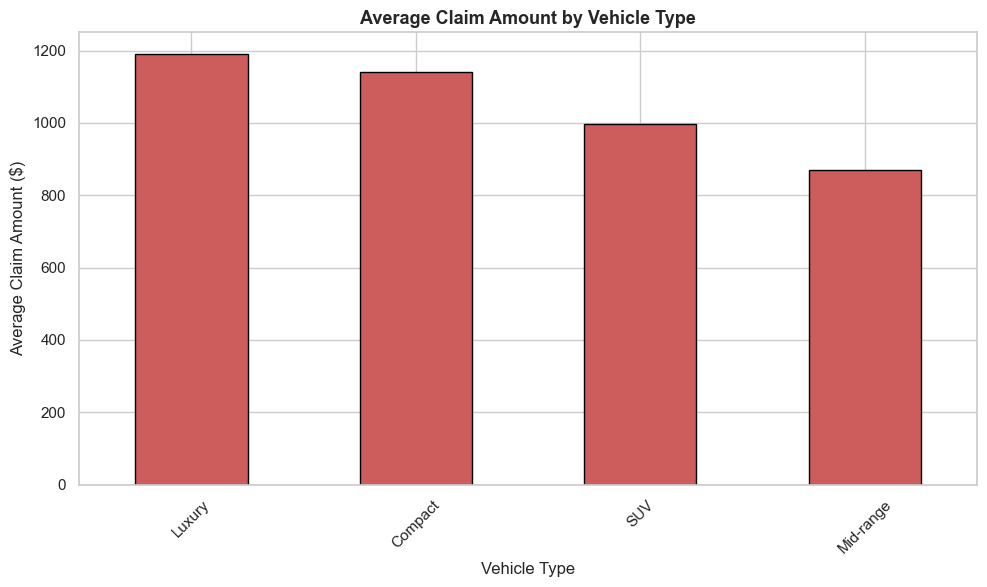

In [12]:
# Task 1: Bar chart - Average Claim Amount by Vehicle Type
fig, ax = plt.subplots(figsize=(10, 6))
avg_claim_vehicle = df.groupby('vehicle_type')['claim_amount'].mean().sort_values(ascending=False)
avg_claim_vehicle.plot(kind='bar', ax=ax, color='indianred', edgecolor='black')
ax.set_xlabel('Vehicle Type', fontsize=12)
ax.set_ylabel('Average Claim Amount ($)', fontsize=12)
ax.set_title('Average Claim Amount by Vehicle Type', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


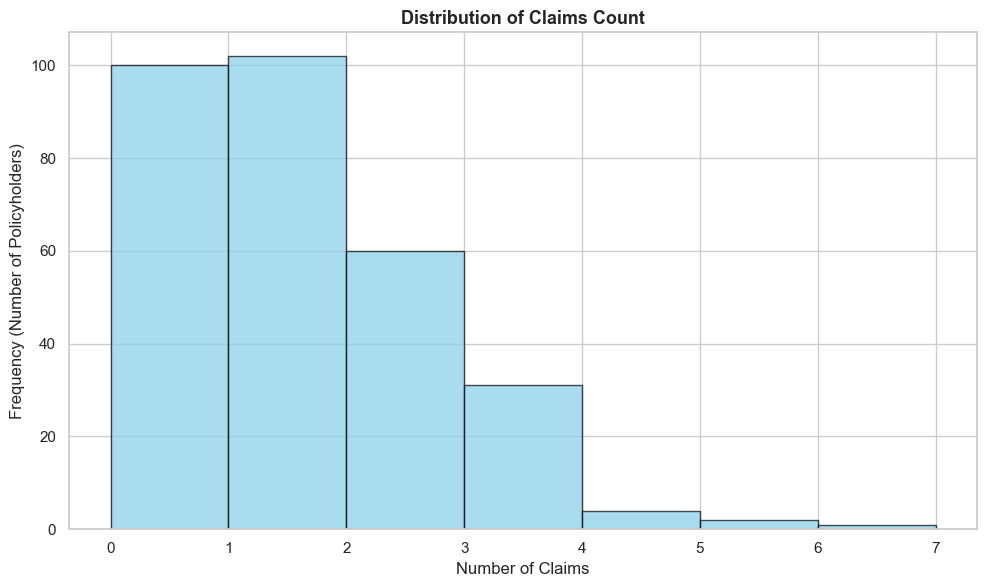

Average claims per policyholder: 1.16
Max claims: 6


In [13]:
# Task 2: Histogram - Distribution of Claims Count
fig, ax = plt.subplots(figsize=(10, 6))
df['claims_count'].plot.hist(bins=range(0, int(df['claims_count'].max())+2), ax=ax, color='skyblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Claims', fontsize=12)
ax.set_ylabel('Frequency (Number of Policyholders)', fontsize=12)
ax.set_title('Distribution of Claims Count', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Average claims per policyholder: {df['claims_count'].mean():.2f}")
print(f"Max claims: {df['claims_count'].max()}")


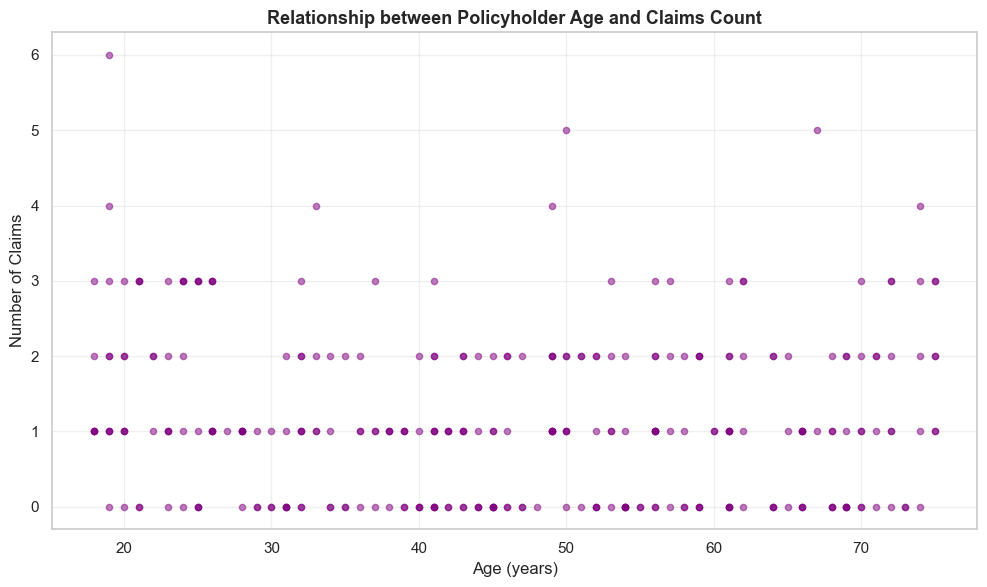

Correlation between age and claims count: -0.076


In [14]:
# Task 3: Scatter plot - Age vs. Claims Count
fig, ax = plt.subplots(figsize=(10, 6))
df.plot.scatter(x='age', y='claims_count', alpha=0.5, ax=ax, color='purple')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Number of Claims', fontsize=12)
ax.set_title('Relationship between Policyholder Age and Claims Count', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Correlation between age and claims count:", df['age'].corr(df['claims_count']).round(3))


## Part 4: Advanced Visualization with Seaborn

Seaborn is a statistical visualization library built on Matplotlib. It provides elegant, high-level interfaces for creating complex visualizations with minimal code.

### 4.1 Distribution Visualization

#### Box Plots
Box plots summarize the distribution of a variable by showing:
- **Median** (center line)
- **Interquartile Range** (box: 25th to 75th percentile)
- **Whiskers** (typically extend to 1.5 × IQR)
- **Outliers** (individual points)

Box plots are ideal for comparing distributions across groups, such as premiums by vehicle type.

#### Violin Plots
Violin plots combine a box plot with a kernel density estimate (KDE). They show:
- The full distribution shape
- Density at different values
- More information than box plots but can be harder to interpret at first glance

### 4.2 Pairplots

A pairplot shows relationships between multiple variables simultaneously. It creates:
- Scatter plots for every pair of numeric variables
- Histograms on the diagonal

This is powerful for exploratory data analysis and identifying patterns in multivariate data.

### Actuarial Application
In insurance analytics, these visualizations help:
- **Identify outliers** (unusual claims or premiums)
- **Compare groups** (e.g., do different regions have different risk profiles?)
- **Find relationships** (do multiple variables move together?)
- **Communicate findings** to non-technical stakeholders


/var/folders/pk/cwgxjc893d9149wsd8y22c9r0000gn/T/ipykernel_85020/2280384260.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='vehicle_type', y='annual_premium', palette='Set2', ax=ax)


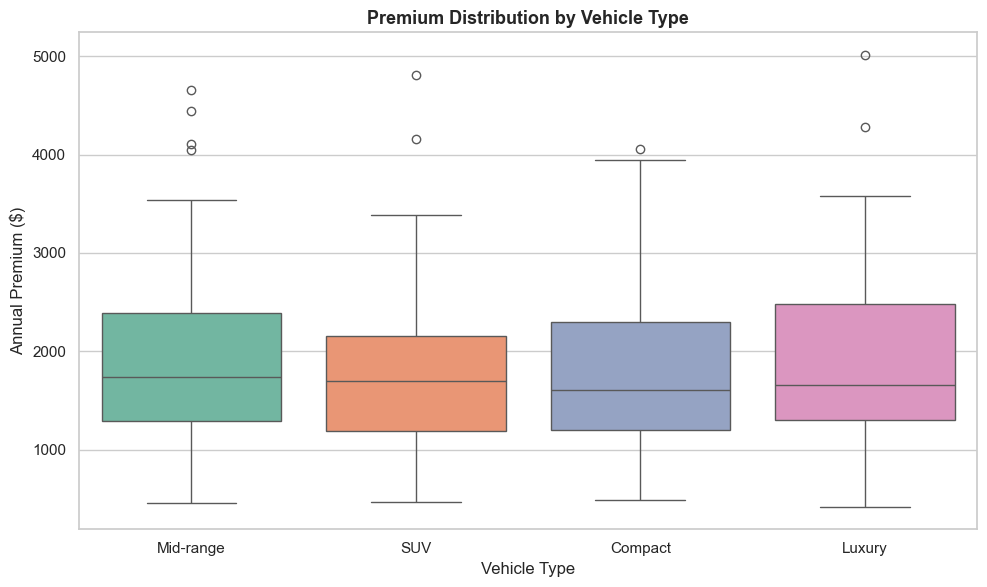

In [15]:
# Plot 1: Box plot - Premium distribution by Vehicle Type
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='vehicle_type', y='annual_premium', palette='Set2', ax=ax)
ax.set_xlabel('Vehicle Type', fontsize=12)
ax.set_ylabel('Annual Premium ($)', fontsize=12)
ax.set_title('Premium Distribution by Vehicle Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


/var/folders/pk/cwgxjc893d9149wsd8y22c9r0000gn/T/ipykernel_85020/3346576513.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='vehicle_type', y='claim_amount', palette='muted', ax=ax)


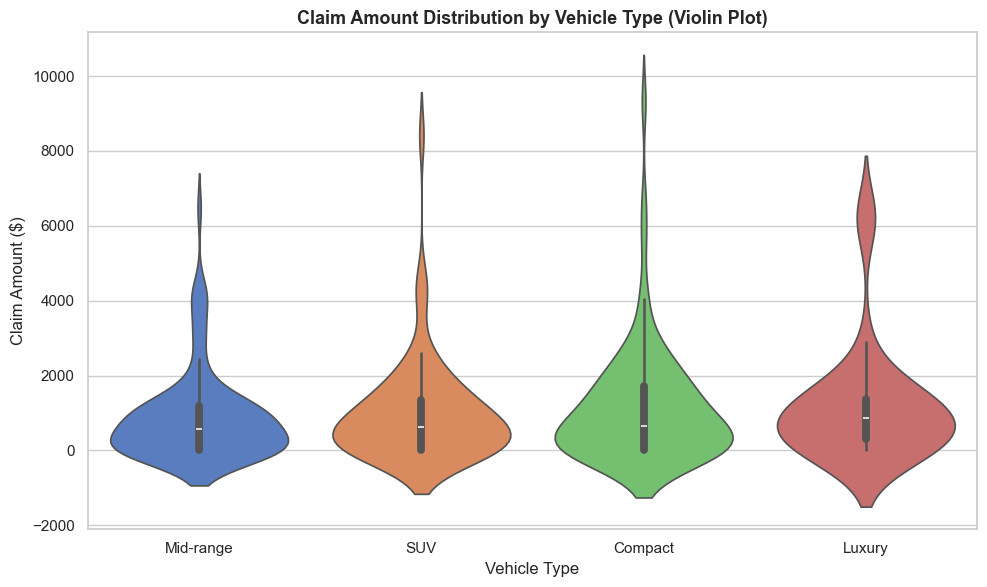

In [16]:
# Plot 2: Violin plot - Claim Amount distribution by Vehicle Type
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x='vehicle_type', y='claim_amount', palette='muted', ax=ax)
ax.set_xlabel('Vehicle Type', fontsize=12)
ax.set_ylabel('Claim Amount ($)', fontsize=12)
ax.set_title('Claim Amount Distribution by Vehicle Type (Violin Plot)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


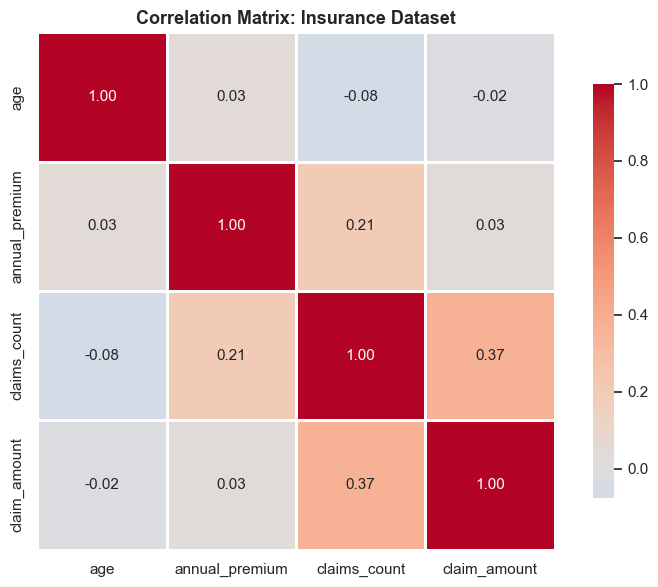

Correlation Matrix:
                     age  annual_premium  claims_count  claim_amount
age             1.000000        0.033249     -0.076346     -0.021455
annual_premium  0.033249        1.000000      0.205191      0.029816
claims_count   -0.076346        0.205191      1.000000      0.370306
claim_amount   -0.021455        0.029816      0.370306      1.000000


In [17]:
# Plot 3: Heatmap - Correlation matrix
# Select numeric columns
numeric_df = df[['age', 'annual_premium', 'claims_count', 'claim_amount']]
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix: Insurance Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(corr_matrix)


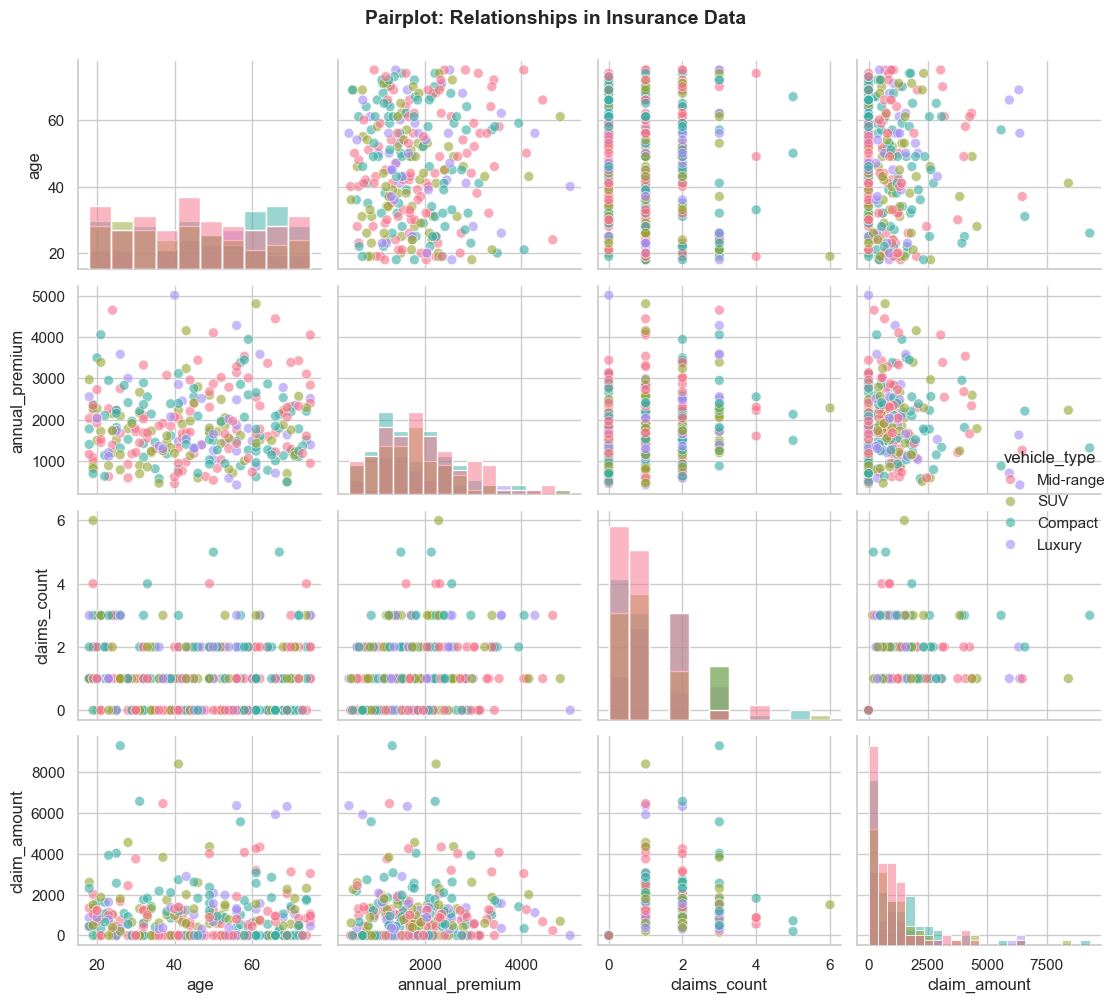

In [18]:
# Plot 4: Pairplot - Relationships between all numeric variables
# Create a subset with numeric columns and one categorical variable for color
pairplot_df = df[['age', 'annual_premium', 'claims_count', 'claim_amount', 'vehicle_type']].copy()

# For better visualization, create pairplot with a subset (to keep it manageable)
g = sns.pairplot(pairplot_df, hue='vehicle_type', palette='husl', diag_kind='hist', 
                 plot_kws={'alpha': 0.6, 's': 50}, height=2.5)
g.fig.suptitle('Pairplot: Relationships in Insurance Data', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


### 4.3 Exercise: Seaborn Visualization Mastery

Create advanced visualizations to explore relationships in the insurance data:

1. **Box plot comparison**: Compare premiums across regions and vehicle types
2. **Distribution analysis**: Create a violin plot for claim amounts by gender
3. **Correlation exploration**: Identify which variables move together most strongly

**Instructions:**
- Use Seaborn functions for elegant, informative visualizations
- Add clear titles and labels
- Discuss what patterns you observe and their actuarial significance


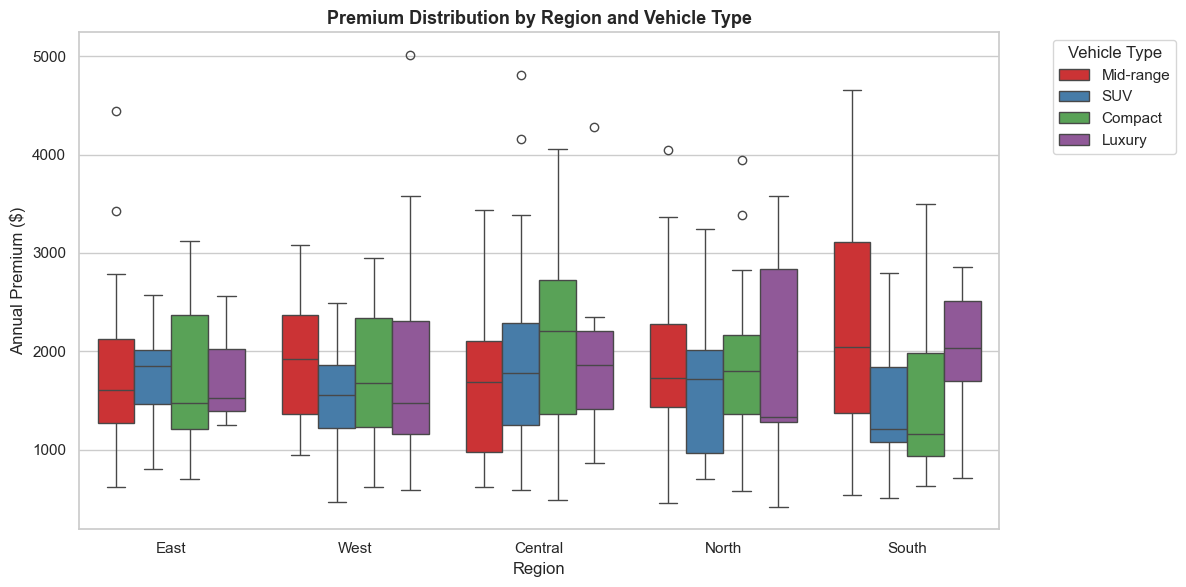

In [19]:
# Task 1: Box plot - Premium by Region and Vehicle Type
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='region', y='annual_premium', hue='vehicle_type', palette='Set1', ax=ax)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Annual Premium ($)', fontsize=12)
ax.set_title('Premium Distribution by Region and Vehicle Type', fontsize=13, fontweight='bold')
ax.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/var/folders/pk/cwgxjc893d9149wsd8y22c9r0000gn/T/ipykernel_85020/4117814105.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='gender', y='claim_amount', palette='muted', ax=ax)


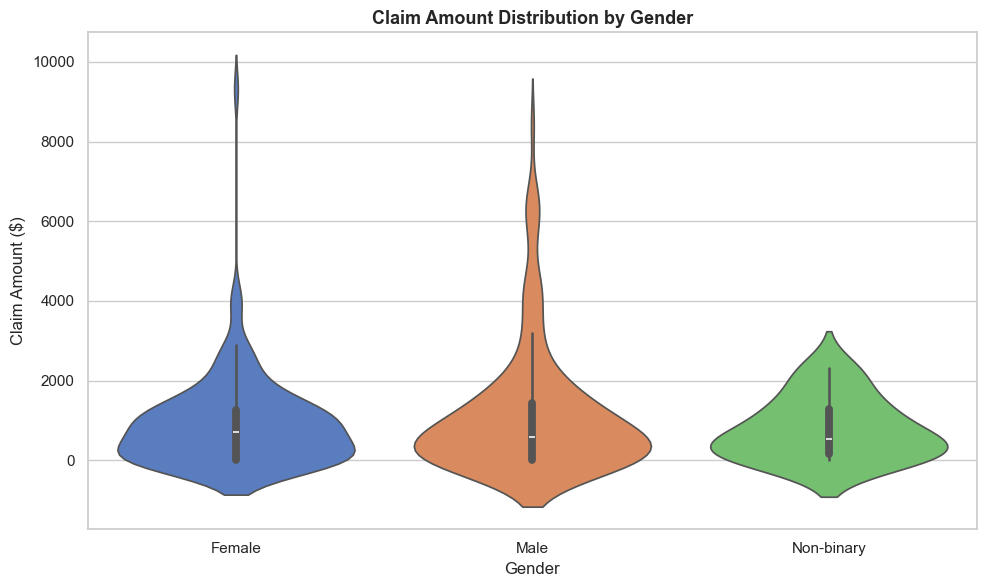

Average claim amount by gender:
                   mean  median          std  count
gender                                             
Female       906.053037  694.98  1153.848827    135
Male        1145.824145  582.11  1594.549594    152
Non-binary   775.090000  529.80   766.766807     13


In [20]:
# Task 2: Violin plot - Claim Amount by Gender
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x='gender', y='claim_amount', palette='muted', ax=ax)
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Claim Amount ($)', fontsize=12)
ax.set_title('Claim Amount Distribution by Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics by gender
print("Average claim amount by gender:")
print(df.groupby('gender')['claim_amount'].agg(['mean', 'median', 'std', 'count']))


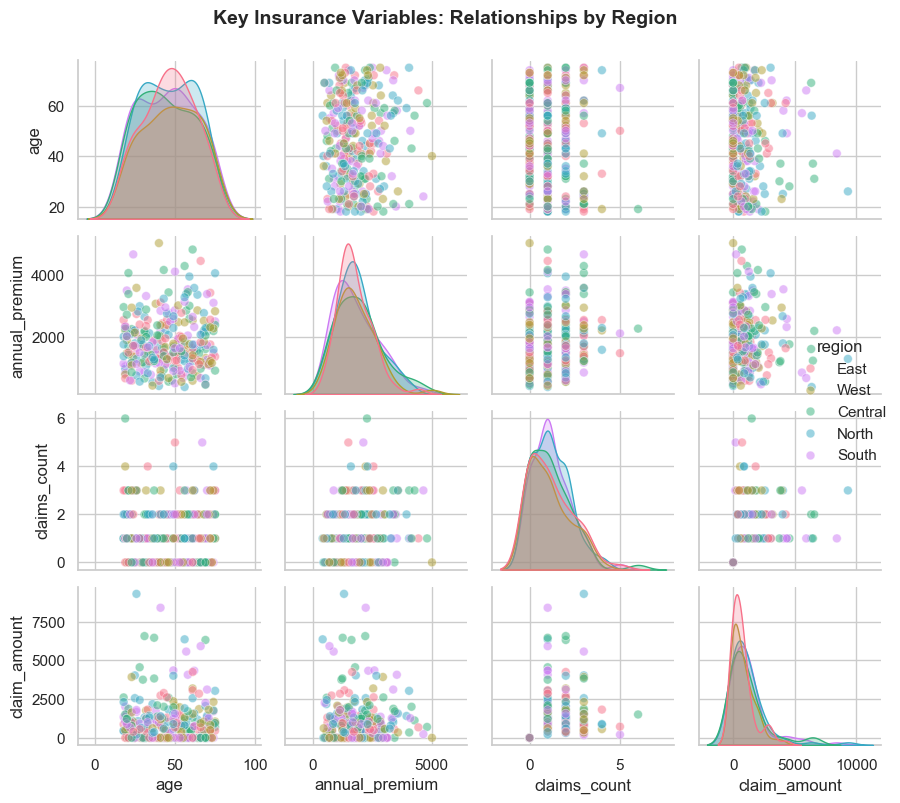

In [21]:
# Task 3: Create a focused pairplot with subset of key variables
# Select key variables for analysis
key_vars = df[['age', 'annual_premium', 'claims_count', 'claim_amount', 'region']].copy()

# Create pairplot with region coloring
g = sns.pairplot(key_vars, hue='region', palette='husl', diag_kind='kde', 
                 plot_kws={'alpha': 0.5, 's': 40}, height=2)
g.fig.suptitle('Key Insurance Variables: Relationships by Region', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## Summary and Key Takeaways

Congratulations! You have now completed a comprehensive introduction to data visualization for insurance analytics using Python.

### What You Have Learned

1. **NumPy Fundamentals**
   - Create and manipulate arrays efficiently
   - Apply vectorized operations to large datasets
   - Work with multi-dimensional data

2. **Pandas Data Manipulation**
   - Load and explore data using DataFrames and Series
   - Perform grouping and aggregation operations
   - Analyze insurance data systematically

3. **Visualization with Pandas**
   - Create scatter plots to explore relationships
   - Use bar charts for categorical comparisons
   - Build histograms to understand distributions

4. **Advanced Visualization with Seaborn**
   - Leverage box plots and violin plots for distribution analysis
   - Build pairplots to investigate multivariate relationships
   - Create heatmaps to visualize correlations

### Actuarial Applications

The techniques covered in this session have direct applications to actuarial work:

- **Premium Modeling**: Understand how policyholder characteristics affect premiums
- **Claims Analysis**: Identify patterns in claim frequency and severity
- **Risk Segmentation**: Compare risk profiles across different groups
- **Portfolio Analysis**: Visualize portfolio composition and characteristics
- **Data Quality**: Detect outliers and data issues early

### Next Steps

To deepen your skills:
1. Practice with your own datasets
2. Explore advanced statistical methods (regression, clustering)
3. Learn about hypothesis testing and confidence intervals
4. Study machine learning approaches for prediction

### Resources

- [NumPy Documentation](https://numpy.org/doc/)
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [Matplotlib User Guide](https://matplotlib.org/stable/users/index.html)
- [Seaborn Tutorial](https://seaborn.pydata.org/tutorial.html)

---

**Thank you for participating in this workshop!** We hope you now feel confident using Python for data visualization and analysis in your actuarial work.
